In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import argparse
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from sklearn.model_selection import StratifiedShuffleSplit
from utils import load_file

In [2]:
data_path = './data'

## Data preparation

Firstly, we will prepare the dataset by cropping small patches of 32X32 around each field as the original images are huge and most of its area are not included in training nor test data.

In [3]:
# List of dates that an observation from Sentinel-2 is provided in the training dataset
dates = [datetime.datetime(2019, 6, 6, 8, 10, 7),
         datetime.datetime(2019, 7, 1, 8, 10, 4),
         datetime.datetime(2019, 7, 6, 8, 10, 8),
         datetime.datetime(2019, 7, 11, 8, 10, 4),
         datetime.datetime(2019, 7, 21, 8, 10, 4),
         datetime.datetime(2019, 8, 5, 8, 10, 7),
         datetime.datetime(2019, 8, 15, 8, 10, 6),
         datetime.datetime(2019, 8, 25, 8, 10, 4),
         datetime.datetime(2019, 9, 9, 8, 9, 58),
         datetime.datetime(2019, 9, 19, 8, 9, 59),
         datetime.datetime(2019, 9, 24, 8, 9, 59),
         datetime.datetime(2019, 10, 4, 8, 10),
         datetime.datetime(2019, 11, 3, 8, 10)]

# List of bands names included in the dataset
bands = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'CLD']

Reading the data

In [4]:
tile_no = 4
bands_arr = np.zeros((tile_no,13,13,3035,2016), dtype = np.float32) # 4 tiles X 13 days X 13 bands X 3035 pixels X 2016 pixels
#read all images
for tile in range(tile_no):
    for idx, d in enumerate(dates): # 2) For each date
        d = ''.join(str(d.date()).split('-')) # Nice date string
        t = str(tile)
        for ibx, b in enumerate(bands): # 3) For each band
            im = load_file(f"{data_path}/{t}/{d}/{t}_{b}_{d}.tif").astype(np.float32)
            # Load im
            #im = load_file(f"{data_path}/{t}/{d}/{t[1]}_{b}_{d}.tif").astype(np.float32)
            # im = load_file(f"{data_path}/ref_african_crops_kenya_02_source/ref_african_crops_kenya_02_tile_{t}_{d}/{b}.tif").astype(np.float32)
            bands_arr[tile,idx,ibx] = im

In [5]:
def create_dataset(bands_arr, radius):
    """
    This a function that go through each field in the data and crop a (2*radius)X(2*radius) patch.
    """
    imgs = np.zeros((4688,13,13,radius*2,radius*2), dtype = np.float32) # patches matrix of dataset_size X 13 days X 13 bands X (2*radius)X(2*radius)
    areas = np.zeros((4688,), dtype = np.int64) # it has the area of each field in the dataset
    gts = np.zeros((4688,), dtype = np.int64) # it has the ground truth of each field in the dataset
    field_masks = np.zeros((4688,1,radius*2,radius*2), dtype = np.float32) # fields matrix that has ones for the pixel belongs to the field, zeros otherwith of dataset_size X (2*radius)X(2*radius)
    fields_arr = []
    ifx = 0
    
    for tile in range(4):
        #load field id and label matrices of the tile
        fids = f"{data_path}/{tile}/{tile}_field_id.tif"
        labs = f"{data_path}/{tile}/{tile}_label.tif"
        # fids = f'{data_path}/ref_african_crops_kenya_02_labels/ref_african_crops_kenya_02_tile_0{tile}_label/field_ids.tif'
        # labs = f'{data_path}/ref_african_crops_kenya_02_labels/ref_african_crops_kenya_02_tile_0{tile}_label/labels.tif'
        field_id = load_file(fids)
        labels = load_file(labs)
        
        for field in np.unique(field_id):
            if field == 0: # if a pixel has 0 as an ID, it means it is not included neither in training nor test data.
              continue
            fields_arr.append(field)
            
            #find pixels belong to current field id
            area_mask = field_id == field
            
            #extract ground-truth class
            area_gt = np.unique(labels[area_mask])[0] 
            
            #calculate the median pixel position to crop around it
            idxx = np.where(area_mask)
            momentx = np.median(idxx[0]).astype(np.int64)
            momenty = np.median(idxx[1]).astype(np.int64)
            
            #create crop
            patch = bands_arr[tile,:,:,max(0, momentx-radius): momentx+radius, max(0, momenty-radius): momenty+radius]
            
            #pad crops in tiles borders with zeros
            imgs[ifx, :, :, :patch.shape[-2], :patch.shape[-1]] = patch
            
            #create crop's field mask (1s for pixels belong to current field id and zeros otherwise)
            field_patch = area_mask[max(0, momentx-radius): momentx+radius, max(0, momenty-radius): momenty+radius]
            
            #pad crop's field mask in tiles borders with zeros
            field_masks[ifx, 0, :patch.shape[-2], :patch.shape[-1]] = field_patch
            
            #make sure the crop's field mask is not empty
            if field_patch.sum() == 0:
                print(ifx, momentx-radius, momentx+radius, momenty-radius, momenty+radius)
            
            #calculate field area
            areas[ifx] = area_mask.sum()
            gts[ifx] = area_gt - 1
            ifx += 1
    
    return imgs, areas, gts, field_masks, fields_arr

In [6]:
#create crops of 32X32 around each field id center
imgs, areas, gts, field_masks, fields_arr = create_dataset(bands_arr, 16)

## Data Exploration

In [7]:
plt.rcParams["figure.figsize"] = (15,10)

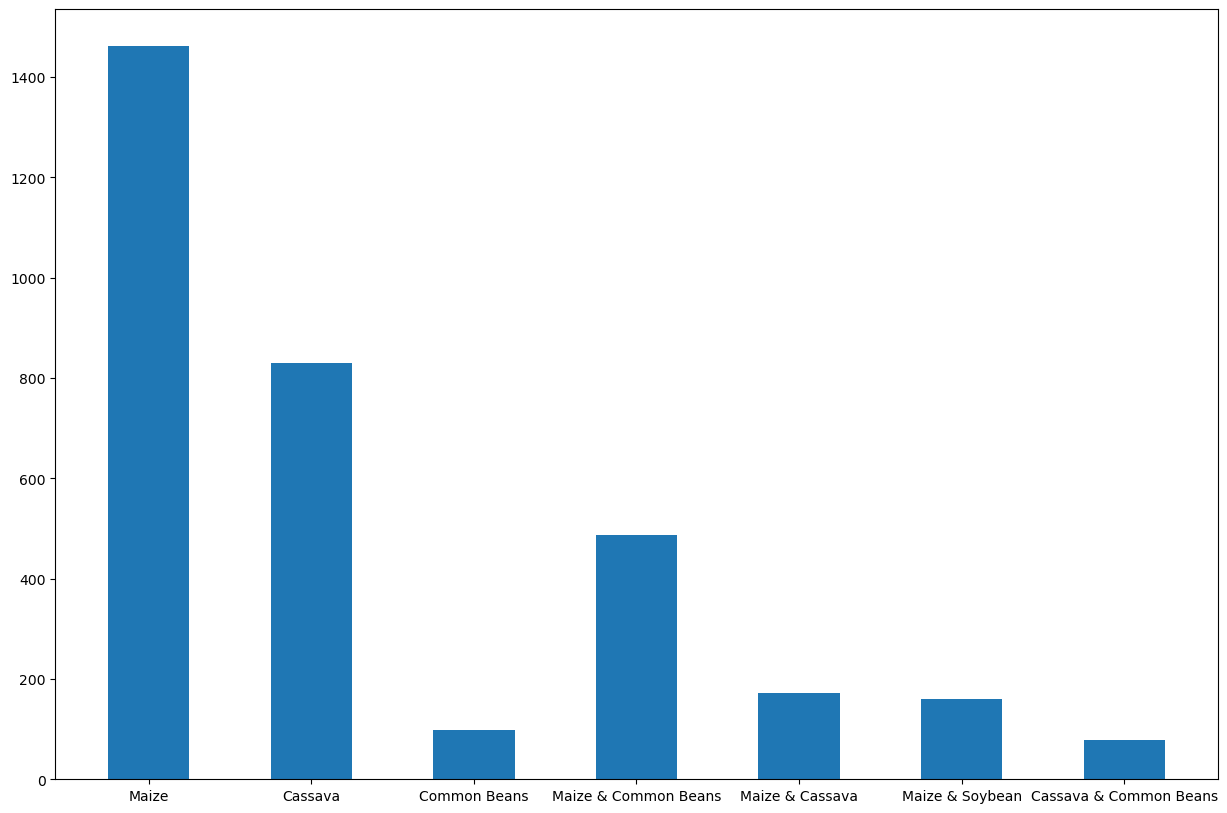

In [8]:
_, counts = np.unique(gts[gts > -1], return_counts=True)
labels = ['Maize', 'Cassava', 'Common Beans', 'Maize & Common Beans', 'Maize & Cassava', 'Maize & Soybean', 'Cassava & Common Beans']
plt.bar(labels, counts, align='center', width = 0.5)
plt.gca().set_xticks(labels)
plt.show()

Text(0, 0.5, 'No. samples')

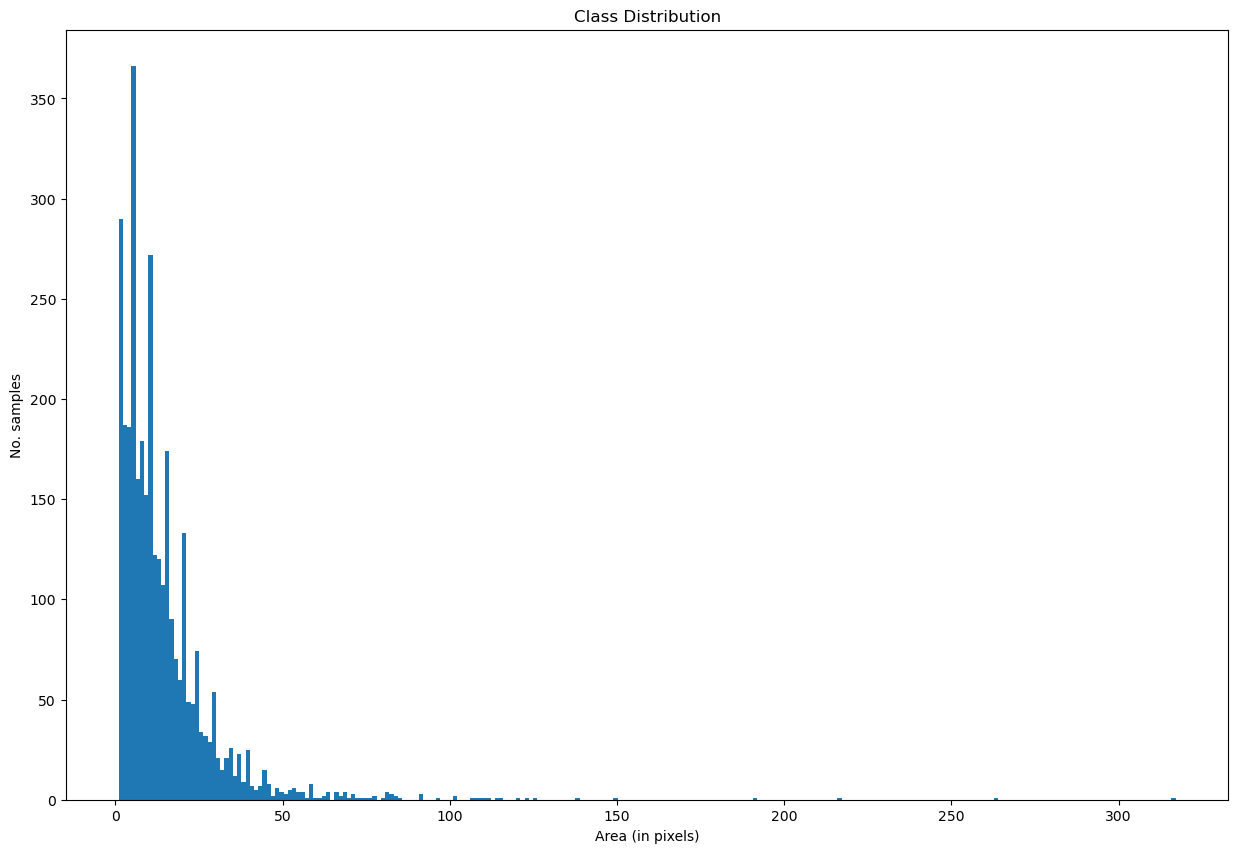

In [9]:
plt.rcParams["figure.figsize"] = (15,10)
plt.hist(areas[gts > -1], bins=250)
plt.title('Class Distribution')
plt.xlabel('Area (in pixels)')
plt.ylabel('No. samples')

In [10]:
band_skewness = []
band_skewness_after_sqrt = []
for c in range(13):
    #calculate skewness
    band_skewness.append(pd.Series(imgs[:,:,c].flatten()).skew())
    #calculate skewness after applying sqrt
    band_skewness_after_sqrt.append(pd.Series(np.sqrt(imgs[:,:,c].flatten())).skew())

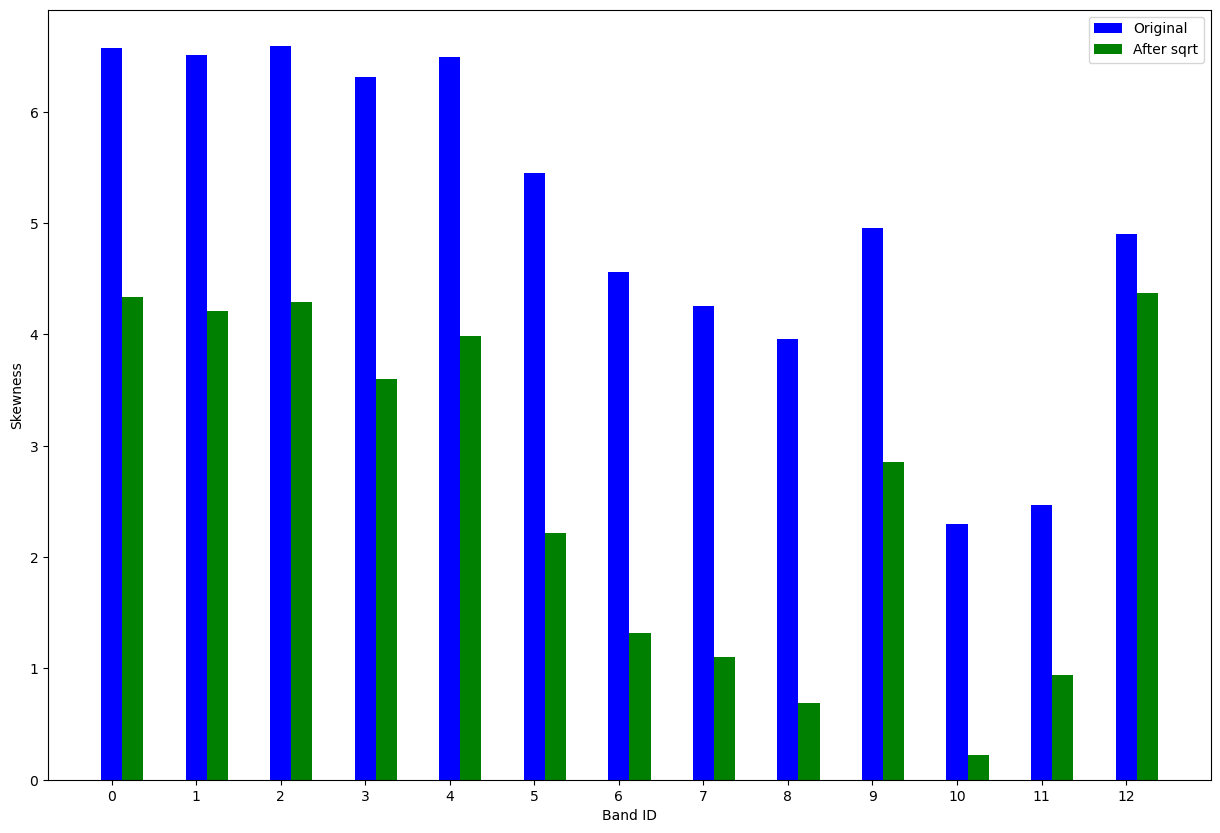

In [11]:
width = 0.25

rng = [i for i in range(0,13)]
rng2 = [i+width for i in range(0,13)]

plt.bar(rng, band_skewness, align='center', width = width, label='Original', color ='b')
plt.bar(rng2, band_skewness_after_sqrt, align='center', width = width, label='After sqrt', color ='g')
plt.gca().set_xticks(rng)
plt.legend()
plt.xlabel('Band ID')
plt.ylabel('Skewness')
plt.show()

## Data Preprocessing

In [16]:
#generate vegitation indecies for training and testing data
ndvi = (imgs[:,:,7:8,:,:] - imgs[:,:,3:4,:,:]) / (imgs[:,:,7:8,:,:] + imgs[:,:,3:4,:,:] + 1e-6)
ndwi_green = (imgs[:,:,2:3,:,:] - imgs[:,:,7:8,:,:]) / (imgs[:,:,2:3,:,:] + imgs[:,:,7:8,:,:] + 1e-6)
ndwi_blue = (imgs[:,:,1:2,:,:] - imgs[:,:,7:8,:,:]) / (imgs[:,:,1:2,:,:] + imgs[:,:,7:8,:,:] + 1e-6)

In [17]:
#apply sqrt to lower skewness
imgs = np.sqrt(imgs)

In [18]:
imgs = np.concatenate([imgs, ndvi, ndwi_green, ndwi_blue], axis = 2)

In [19]:
#data standardization
for c in range(imgs.shape[2]):
    mean = imgs[:, :, c].mean()
    std = imgs[:, :, c].std()
    imgs[:, :, c] = (imgs[:, :, c] - mean) / std

## Local validation strategy

In [20]:
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.15, random_state=0)

## Model training

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from dataset import ICLRDataset
from model import ConvGRUNet
from utils import test, train_model_snapshot

In [22]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

#set all seeds
torch.manual_seed(0)
np.random.seed(0)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [23]:
SAVE_DIR = 'checkpoints'

In [19]:
os.makedirs(SAVE_DIR, exist_ok=True)

models_arr = []
fold = 0
for train_index, val_index in sss.split(areas[gts > -1], gts[gts > -1]):
    print(f"Fold {fold}")
    image_datasets = {'train': ICLRDataset(imgs, areas, gts, field_masks, 'train', train_index),
                      'val': ICLRDataset(imgs, areas, gts, field_masks, 'val', val_index),
                      'test': ICLRDataset(imgs, areas, gts, field_masks, 'test', None)}

    dataloaders = {'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=16, shuffle=True, num_workers=16),
                   'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=16, shuffle=False, num_workers=16)}

    model_ft = ConvGRUNet(imgs.shape[2]-1).to(device)
    criterion = nn.CrossEntropyLoss()
    dataset_sizes = {x:len(image_datasets[x]) for x in ['train', 'val']}
    
    #train a model on this data split using snapshot ensemble
    model_ft_arr, _, _ = train_model_snapshot(model_ft, criterion, 0.008, dataloaders, dataset_sizes, device,
                           num_cycles=6, num_epochs_per_cycle=10)
    # Save every snapshot from this fold
    for snap_idx, m in enumerate(model_ft_arr):
        ckpt_path = os.path.join(SAVE_DIR, f'fold{fold}_snap{snap_idx}.pt')
        torch.save(m.state_dict(), ckpt_path)
        print(f"  saved {ckpt_path}")
        
    models_arr.extend(model_ft_arr)
    fold += 1

# Optional: also save the count + input channel size so loading is self-contained
torch.save({'in_channels': imgs.shape[2] - 1, 'n_models': len(models_arr)}, os.path.join(SAVE_DIR, 'meta.pt'))

Fold 0
Cycle 0: Epoch 0/9
----------
train Loss: 1.4879 Acc: 0.4765
val Loss: 1.4020 Acc: 0.5477

Cycle 0: Epoch 1/9
----------
train Loss: 1.3831 Acc: 0.5184
val Loss: 1.3833 Acc: 0.5213

Cycle 0: Epoch 2/9
----------
train Loss: 1.3472 Acc: 0.5281
val Loss: 1.3232 Acc: 0.5517

Cycle 0: Epoch 3/9
----------
train Loss: 1.3204 Acc: 0.5342
val Loss: 1.2849 Acc: 0.5801

Cycle 0: Epoch 4/9
----------
train Loss: 1.2724 Acc: 0.5535
val Loss: 1.2830 Acc: 0.5659

Cycle 0: Epoch 5/9
----------
train Loss: 1.2483 Acc: 0.5603
val Loss: 1.2322 Acc: 0.5882

Cycle 0: Epoch 6/9
----------
train Loss: 1.2188 Acc: 0.5668
val Loss: 1.2245 Acc: 0.5680

Cycle 0: Epoch 7/9
----------
train Loss: 1.1960 Acc: 0.5825
val Loss: 1.2061 Acc: 0.5822

Cycle 0: Epoch 8/9
----------
train Loss: 1.1682 Acc: 0.5940
val Loss: 1.2056 Acc: 0.5781

Cycle 0: Epoch 9/9
----------
train Loss: 1.1567 Acc: 0.5990
val Loss: 1.1964 Acc: 0.5862

Cycle 1: Epoch 0/9
----------
train Loss: 1.2690 Acc: 0.5507
val Loss: 1.2689 Acc: 

## Model inference

In [13]:
import glob

def load_ensemble(ckpt_dir, in_channels, device, pattern='fold*_snap*.pt'):
    paths = sorted(glob.glob(os.path.join(ckpt_dir, pattern)))
    models = []
    for p in paths:
        m = ConvGRUNet(in_channels).to(device)
        m.load_state_dict(torch.load(p, map_location=device))
        m.eval()
        models.append(m)
    print(f"Loaded {len(models)} models from {ckpt_dir}")
    return models

In [24]:
# Reconstruct
meta = torch.load(os.path.join(SAVE_DIR, 'meta.pt'))
models_arr = load_ensemble(SAVE_DIR, meta['in_channels'], device)

Loaded 60 models from checkpoints


In [26]:
test_dataset = ICLRDataset(imgs, areas, gts, field_masks, 'test', None)
test_loader  = torch.utils.data.DataLoader(
    test_dataset, batch_size=16, shuffle=False, num_workers=4
)
# test_loader = torch.utils.data.DataLoader(image_datasets['test'], batch_size=16, shuffle=False, num_workers=4)
res = test(models_arr, test_loader, device)

## Make a submission

In [ ]:
sample_submission_path = 'SampleSubmission.csv'
test_fields_arr = np.array(fields_arr)[gts == -1]
sub = pd.read_csv(sample_submission_path)
sub['Field_ID'] = test_fields_arr.tolist()
for i in range(res.shape[1]):
    sub['Crop_ID_%d'%(i+1)] = res[:,i].tolist()
sub.to_csv('sub.csv', index = False)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import seaborn as sns

class_names = ['Maize', 'Cassava', 'Common Beans', 'Maize & Common Beans',
               'Maize & Cassava', 'Maize & Soybean', 'Cassava & Common Beans']

# `res` is shape (N_test, n_classes) — softmax-averaged across the ensemble
test_preds       = res.argmax(axis=1)
test_confidences = res.max(axis=1)
test_field_ids   = np.array(fields_arr)[gts == -1]
print(f"{len(test_preds)} test fields, {res.shape[1]} classes")

1402 test fields, 7 classes


## Predicted class distribution (test) vs. training distribution
Sanity check: if the predicted distribution looks wildly different from what the model saw in training, that's a red flag.

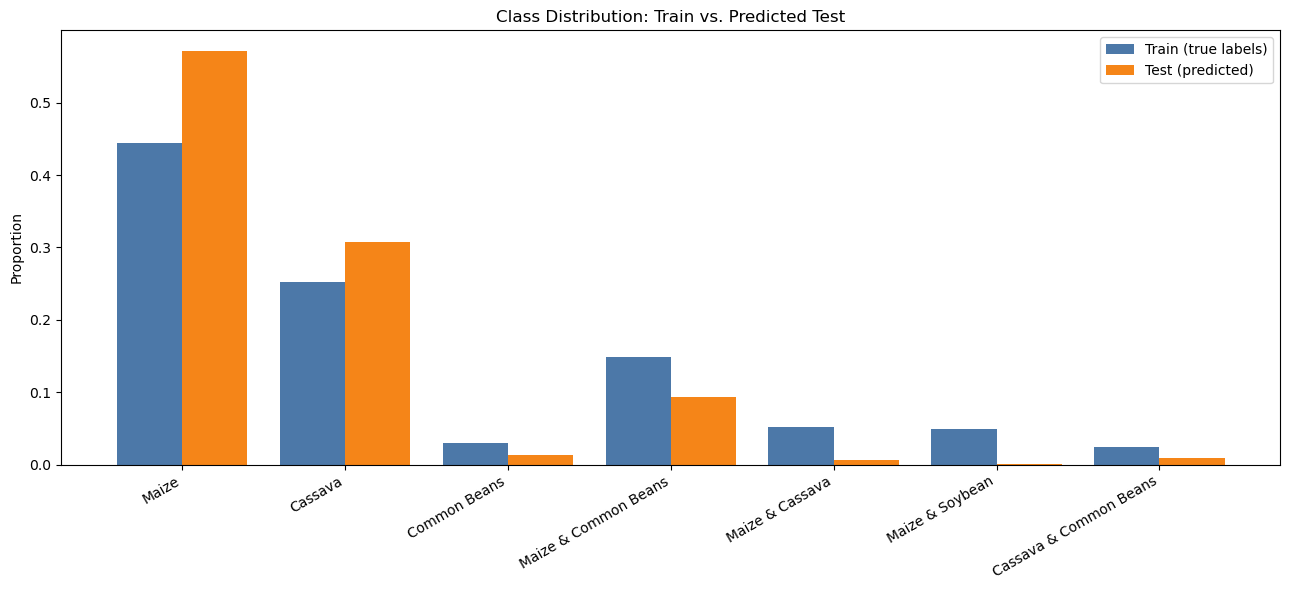

  Maize                           predicted:  801 ( 57.1%)
  Cassava                         predicted:  432 ( 30.8%)
  Common Beans                    predicted:   18 (  1.3%)
  Maize & Common Beans            predicted:  130 (  9.3%)
  Maize & Cassava                 predicted:    8 (  0.6%)
  Maize & Soybean                 predicted:    1 (  0.1%)
  Cassava & Common Beans          predicted:   12 (  0.9%)


In [28]:
train_counts = np.bincount(gts[gts > -1], minlength=len(class_names))
test_counts  = np.bincount(test_preds,    minlength=len(class_names))

train_pct = train_counts / train_counts.sum()
test_pct  = test_counts  / test_counts.sum()

x = np.arange(len(class_names)); w = 0.4
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, train_pct, w, label='Train (true labels)', color='#4c78a8')
ax.bar(x + w/2, test_pct,  w, label='Test (predicted)',    color='#f58518')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Proportion'); ax.set_title('Class Distribution: Train vs. Predicted Test')
ax.legend(); plt.tight_layout(); plt.show()

for i, n in enumerate(class_names):
    print(f"  {n:30s}  predicted: {test_counts[i]:4d} ({test_pct[i]*100:5.1f}%)")

## Confidence distribution

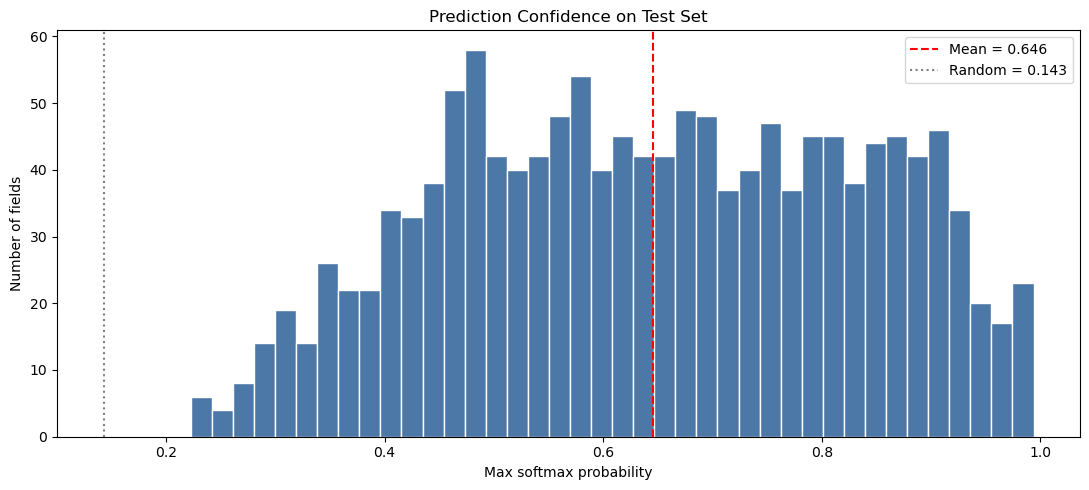

Median confidence:  0.646
Low-confidence (<0.4):  142 fields
High-confidence (>0.8): 356 fields


In [29]:
plt.figure(figsize=(11, 5))
plt.hist(test_confidences, bins=40, color='#4c78a8', edgecolor='white')
plt.axvline(test_confidences.mean(), color='red', ls='--',
            label=f'Mean = {test_confidences.mean():.3f}')
plt.axvline(1/len(class_names), color='gray', ls=':',
            label=f'Random = {1/len(class_names):.3f}')
plt.xlabel('Max softmax probability'); plt.ylabel('Number of fields')
plt.title('Prediction Confidence on Test Set'); plt.legend()
plt.tight_layout(); plt.show()

print(f"Median confidence:  {np.median(test_confidences):.3f}")
print(f"Low-confidence (<0.4):  {(test_confidences < 0.4).sum()} fields")
print(f"High-confidence (>0.8): {(test_confidences > 0.8).sum()} fields")

## Per-class predicted confidence
How sure is the model when it predicts each crop type? Low mean confidence on a class often means the model is guessing it as a fallback.

/tmp/ipykernel_741886/741269615.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=class_names, patch_artist=True, showmeans=True)


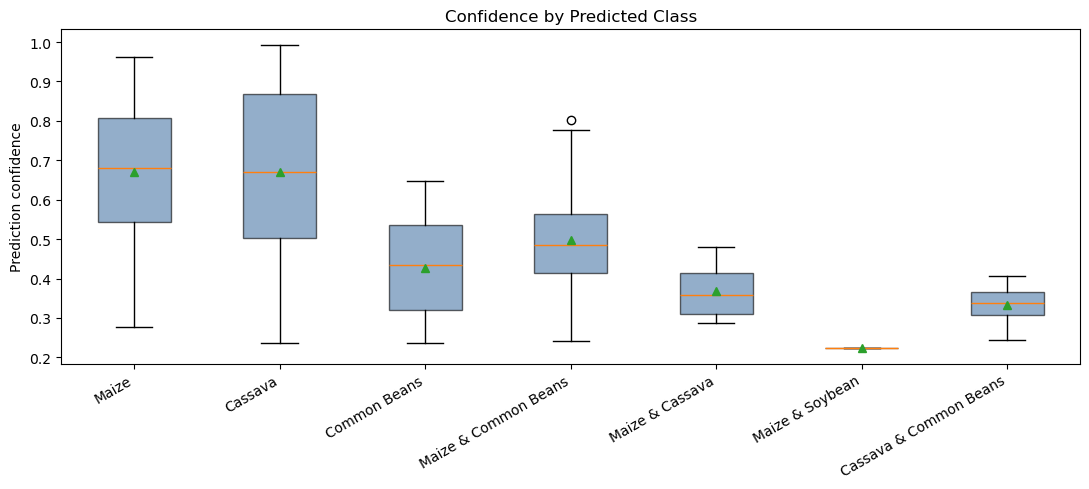

In [30]:
fig, ax = plt.subplots(figsize=(11, 5))
data = [test_confidences[test_preds == c] for c in range(len(class_names))]
bp = ax.boxplot(data, labels=class_names, patch_artist=True, showmeans=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4c78a8'); patch.set_alpha(0.6)
ax.set_ylabel('Prediction confidence')
ax.set_title('Confidence by Predicted Class')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Sample test patches with predictions
Visualize some field patches as RGB composites. Bands B04/B03/B02 (red/green/blue) live at indices 3/2/1. Since imgs has been sqrt'd and standardized, we percentile-stretch for display.

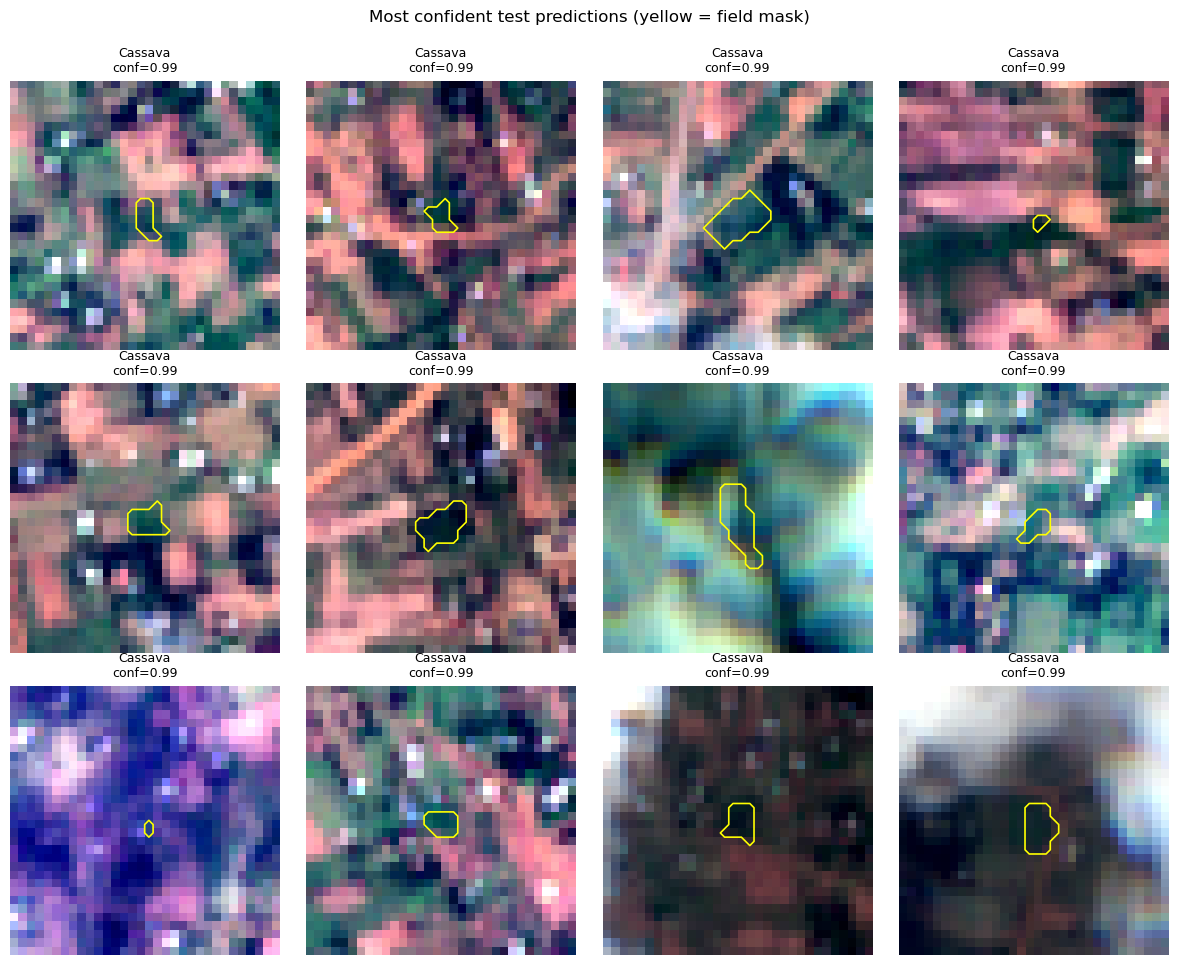

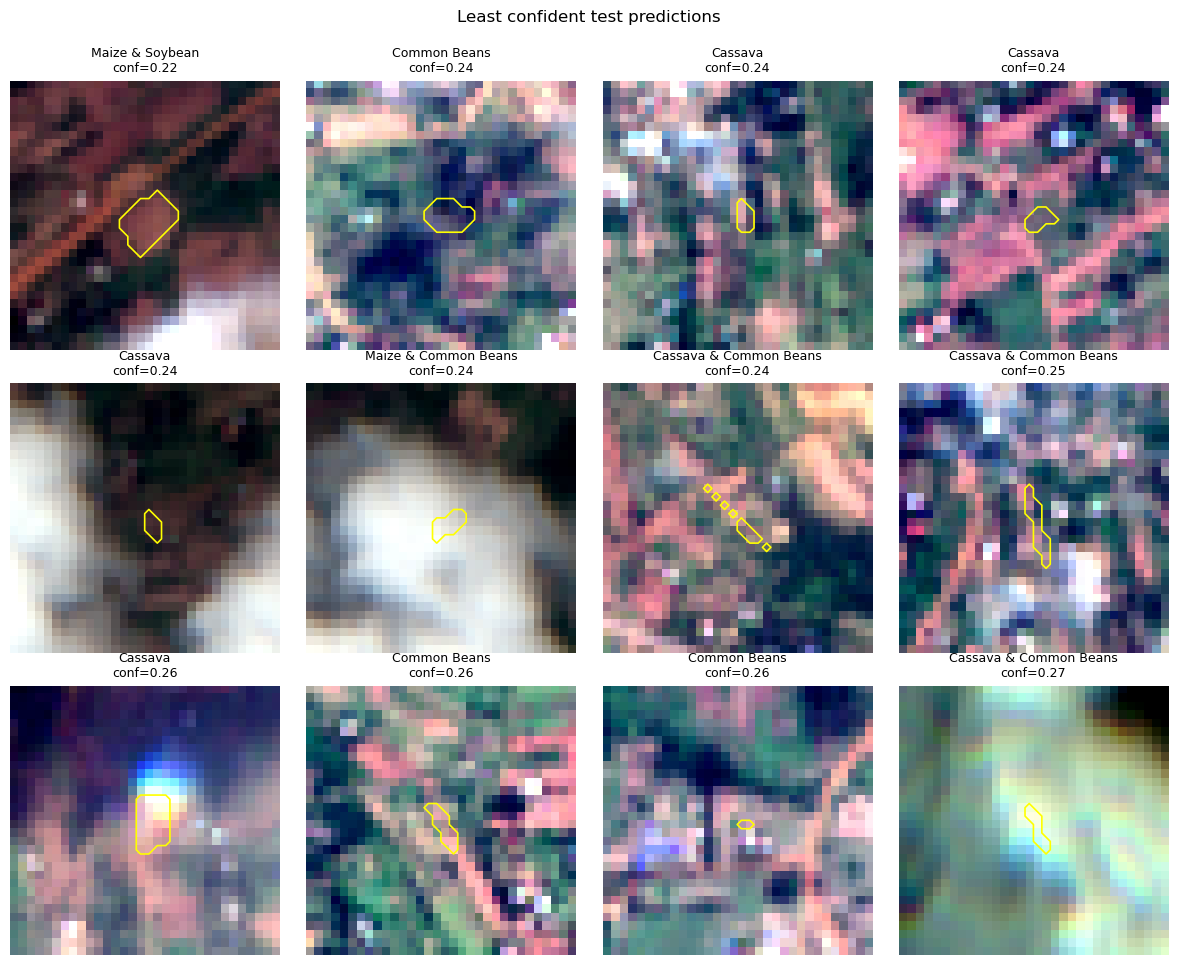

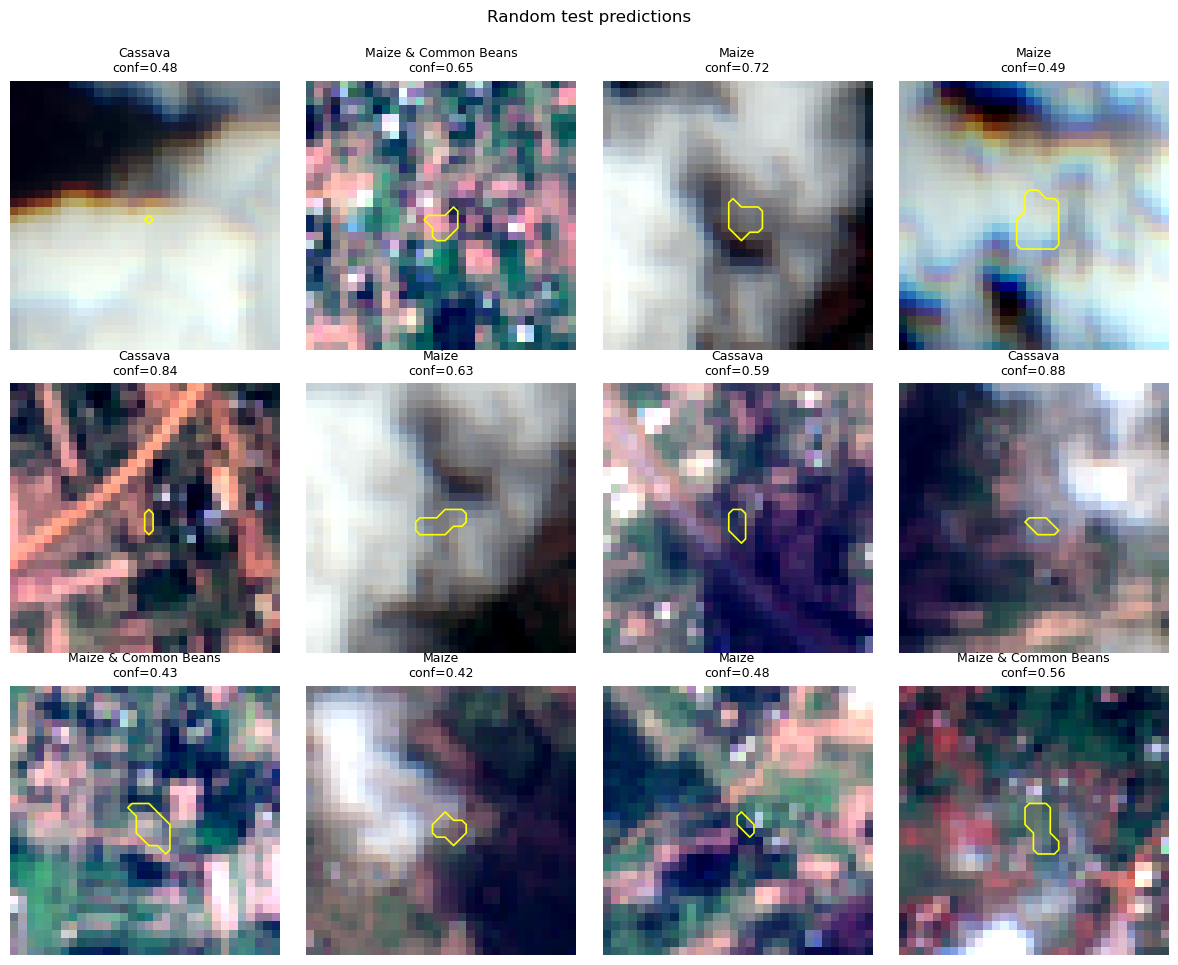

In [33]:
def patch_to_rgb(patch_img, field_mask, day_idx=5):
    """patch_img shape: (n_days, n_channels, H, W). Pull RGB from one date."""
    rgb = patch_img[day_idx, [3, 2, 1]].transpose(1, 2, 0)  # H, W, 3
    lo, hi = np.percentile(rgb, [2, 98])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    return rgb, field_mask[0]

test_idx_global = np.where(gts == -1)[0]  # positions in `imgs`/`field_masks`

def show_samples(local_indices, title):
    n = len(local_indices)
    cols = 4; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for ax, li in zip(axes, local_indices):
        gi = test_idx_global[li]
        rgb, mask = patch_to_rgb(imgs[gi], field_masks[gi])
        ax.imshow(rgb); ax.contour(mask, levels=[0.5], colors='yellow', linewidths=1.2)
        ax.set_title(f"{class_names[test_preds[li]]}\n"
                     f"conf={test_confidences[li]:.2f}", fontsize=9)
        ax.axis('off')
    for ax in axes[n:]: ax.axis('off')
    fig.suptitle(title, y=1.0); plt.tight_layout(); plt.show()

# Most confident, least confident, and a random sample
top  = np.argsort(test_confidences)[-12:][::-1]
bot  = np.argsort(test_confidences)[:12]
rng  = np.random.RandomState(0).choice(len(test_preds), 12, replace=False)

show_samples(top, "Most confident test predictions (yellow = field mask)")
show_samples(bot, "Least confident test predictions")
show_samples(rng, "Random test predictions")

## Class-probability heatmap for uncertain predictions
For the lowest-confidence cases, show the full probability across classes — reveals which crops the model is torn between.

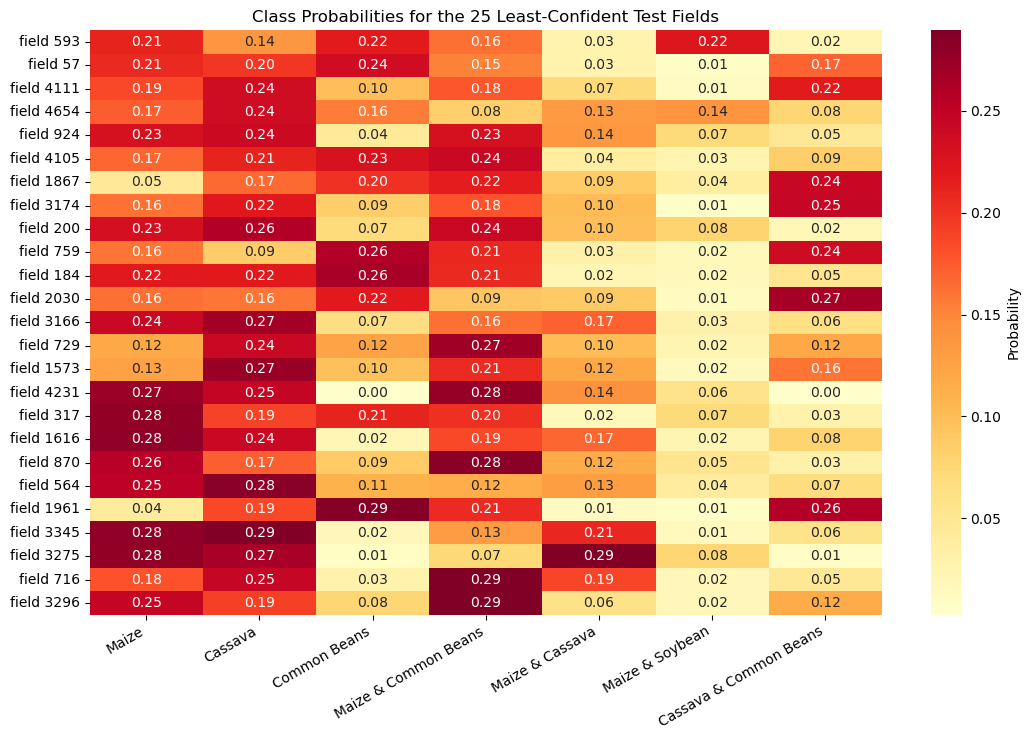

In [34]:
n_show = 25
worst = np.argsort(test_confidences)[:n_show]

plt.figure(figsize=(11, max(6, n_show * 0.3)))
sns.heatmap(res[worst], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names,
            yticklabels=[f"field {test_field_ids[i]}" for i in worst],
            cbar_kws={'label': 'Probability'})
plt.title(f'Class Probabilities for the {n_show} Least-Confident Test Fields')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

## Validation-set evaluation (this is where you get a confusion matrix)
The test set has no labels, so to actually measure quality you need to run inference on the val split. This rebuilds the val loader from the last fold and computes the things you'd want.

In [38]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=10, test_size=0.15, random_state=0)
splits = list(sss.split(areas[gts > -1], gts[gts > -1]))

fold_to_eval = 9                   # last fold; change to evaluate a different one
train_index, val_index = splits[fold_to_eval]

val_dataset = ICLRDataset(imgs, areas, gts, field_masks, 'val', val_index)
val_loader  = torch.utils.data.DataLoader(
    val_dataset, batch_size=16, shuffle=False, num_workers=4
)

In [40]:
batch = next(iter(val_loader))
print(f"batch has {len(batch)} items")
for i, x in enumerate(batch):
    print(f"  [{i}] {type(x).__name__}  shape={getattr(x, 'shape', None)}")

batch has 4 items
  [0] Tensor  shape=torch.Size([16, 13, 15, 32, 32])
  [1] Tensor  shape=torch.Size([16, 1])
  [2] Tensor  shape=torch.Size([16, 1, 32, 32])
  [3] Tensor  shape=torch.Size([16])


Validation accuracy: 0.7160


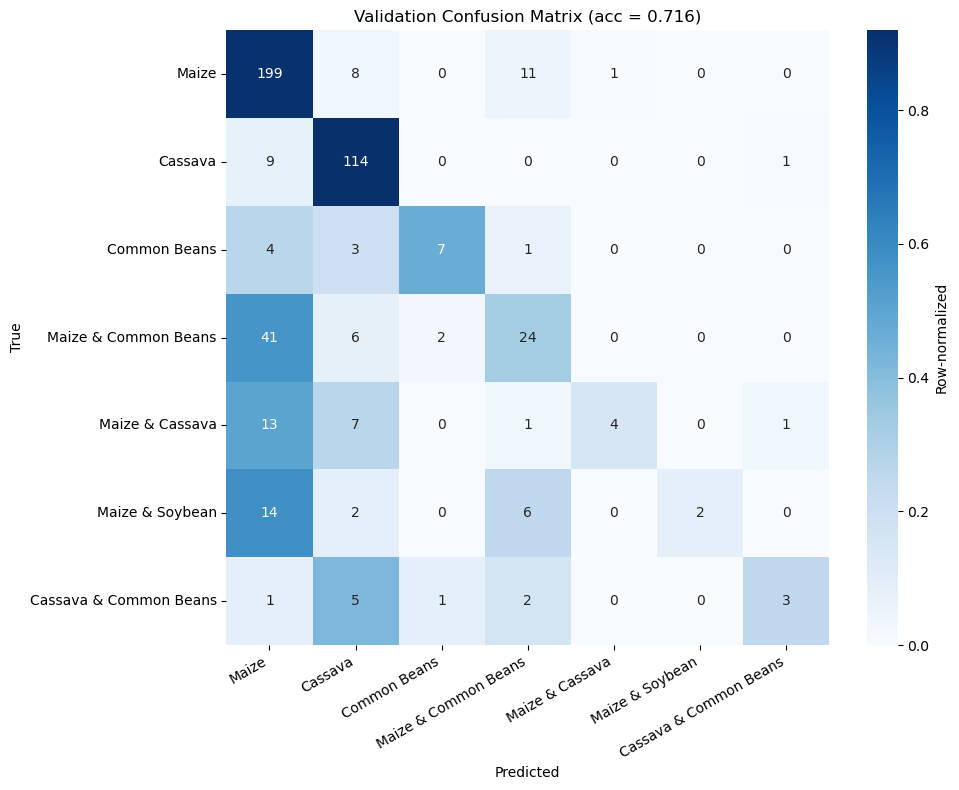

                        precision    recall  f1-score   support

                 Maize      0.708     0.909     0.796       219
               Cassava      0.786     0.919     0.848       124
          Common Beans      0.700     0.467     0.560        15
  Maize & Common Beans      0.533     0.329     0.407        73
       Maize & Cassava      0.800     0.154     0.258        26
       Maize & Soybean      1.000     0.083     0.154        24
Cassava & Common Beans      0.600     0.250     0.353        12

              accuracy                          0.716       493
             macro avg      0.733     0.444     0.482       493
          weighted avg      0.718     0.716     0.674       493



In [42]:
from sklearn.metrics import confusion_matrix, classification_report

# Reuse the val split from the last fold of training
# val_loader = torch.utils.data.DataLoader(
#     image_datasets['val'], batch_size=16, shuffle=False, num_workers=4
# )

@torch.no_grad()
def ensemble_eval(models, loader, device):
    for m in models:
        m.eval()
    all_probs, all_labels = [], []
    for images, _areas, masks, labels in loader:
        images = images.to(device)
        masks  = masks.to(device)
        probs = torch.zeros(images.size(0), len(class_names), device=device)
        for m in models:
            probs += F.softmax(m(images, masks), dim=1)
        probs /= len(models)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

val_probs, val_labels = ensemble_eval(models_arr, val_loader, device)
val_preds = val_probs.argmax(1)
val_acc   = (val_preds == val_labels).mean()
print(f"Validation accuracy: {val_acc:.4f}")

cm = confusion_matrix(val_labels, val_preds, labels=list(range(len(class_names))))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Row-normalized'})
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Validation Confusion Matrix (acc = {val_acc:.3f})')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(classification_report(val_labels, val_preds,
                            target_names=class_names, digits=3, zero_division=0))